# Rain in Australia :

our problem is to predict if the next day in australia will be rainy or not , so we will build a classefier to find a decision boundary that separate rainy days and normal days .

#### Dataset overview :

our dataset has 150000 records for 41 australian city weather from 2007 to 2017 .
and it has 23 weather features like cloud , pressure , humidity , evaporation , etc...




In [ ]:
%matplotlib notebook
import warnings;
warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools


sns.set(rc={'figure.figsize':(10,6)})


In [ ]:

# Reading and discovering the dataset :

orginal_dataset = pd.read_csv('C://Users//User//Desktop//weatherAUS.csv')
print('columns :' + str(orginal_dataset.columns))
orginal_dataset.head()

columns :Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
# Discovering data shape :

print('Austrlia Rain Dataset has :')
print()
print('{} days records '.format(orginal_dataset.shape[0]) )
print('{} weather features '.format(orginal_dataset.shape[1]))
print()
print('Dataset Information :')
orginal_dataset.info()

Austrlia Rain Dataset has :

145460 days records 
23 weather features 

Dataset Information :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
Date             145460 non-null object
Location         145460 non-null object
MinTemp          143975 non-null float64
MaxTemp          144199 non-null float64
Rainfall         142199 non-null float64
Evaporation      82670 non-null float64
Sunshine         75625 non-null float64
WindGustDir      135134 non-null object
WindGustSpeed    135197 non-null float64
WindDir9am       134894 non-null object
WindDir3pm       141232 non-null object
WindSpeed9am     143693 non-null float64
WindSpeed3pm     142398 non-null float64
Humidity9am      142806 non-null float64
Humidity3pm      140953 non-null float64
Pressure9am      130395 non-null float64
Pressure3pm      130432 non-null float64
Cloud9am         89572 non-null float64
Cloud3pm         86102 non-null float64
Temp9am          143693 n

<IPython.core.display.Javascript object>


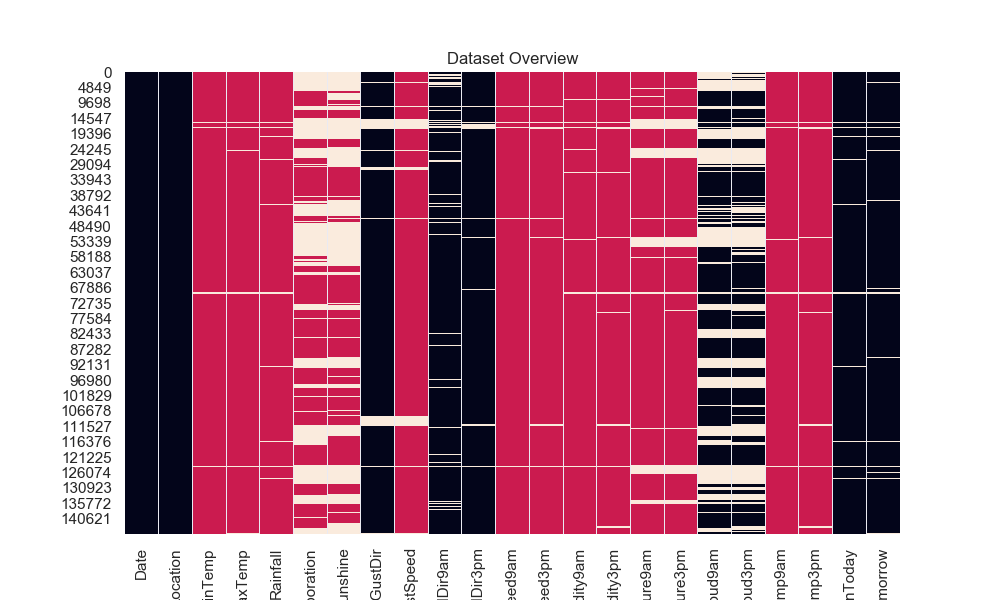

 Categerocial   Numeric   NaN 


In [ ]:
def utils_recognize_type(df, col, max_cat=20):
    if (df[col].dtype == "O") | (df[col].nunique() < max_cat):
        return "cat"
    else:
        return "num"
def show_dataset_details(df):
    dic_cols = {col:utils_recognize_type(df, col, max_cat=20) for col in df.columns}
    heatmap = df.isnull()
    for k,v in dic_cols.items():
        if v == "num":
            heatmap[k] = heatmap[k].apply(lambda x: 0.5 if x is False else 1)
        else:
            heatmap[k] = heatmap[k].apply(lambda x: 0 if x is False else 1)
    sns.heatmap(heatmap, cbar=False).set_title('Dataset Overview')
    plt.show()
    print("\033[1;37;40m Categerocial ", "\033[1;30;41m Numeric ", "\033[1;30;47m NaN ")
show_dataset_details(orginal_dataset)

In [ ]:
orginal_dataset.isna().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

We notice that evaporation and sunshine features have too many nan value , and if we drop the records that have missing values we will lost too many data so we will delete these two features , and we see that cloud features have too many missing value too , but cloud features are very important so we will not delete them .

In [ ]:
del orginal_dataset['Evaporation']
del orginal_dataset['Sunshine']

In [ ]:
# Removing records that have missing values :
not_nan_dataset = orginal_dataset.dropna()
print(not_nan_dataset.shape)
not_nan_dataset.head()


(71045, 21)


,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
4,2008-12-05,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
11,2008-12-12,Albury,15.9,21.7,2.2,NNE,31.0,NE,ENE,15.0,...,89.0,91.0,1010.5,1004.2,8.0,8.0,15.9,17.0,Yes,Yes
12,2008-12-13,Albury,15.9,18.6,15.6,W,61.0,NNW,NNW,28.0,...,76.0,93.0,994.3,993.0,8.0,8.0,17.4,15.8,Yes,Yes
16,2008-12-17,Albury,14.1,20.9,0.0,ENE,22.0,SSW,E,11.0,...,69.0,82.0,1012.2,1010.4,8.0,1.0,17.2,18.1,No,Yes
17,2008-12-18,Albury,13.5,22.9,16.8,W,63.0,N,WNW,6.0,...,80.0,65.0,1005.8,1002.2,8.0,1.0,18.0,21.5,Yes,Yes


In [ ]:
# Discovering classes of the dataset
not_nan_dataset['RainTomorrow'].value_counts()

No     54294
Yes    16751
Name: RainTomorrow, dtype: int64

# Data Visualization :


We should know that the seasons in Australia are :

summer : 1/12 -> 30/2
autumn : 1/3 -> 30/5
winter : 1/6 -> 30/8
spring : 1/9 -> 30/11



## Location :

We noticed that : in some cities count of positive example are heigher than negatives , and in other cities vice versa , but this information may not be true because we had deleted the records that have missing value .

Lets see the same plot in orginal data :

In [ ]:
not_nan_dataset['Location'].value_counts()

Darwin              3115
Perth               3031
Brisbane            3017
MelbourneAirport    2933
SydneyAirport       2925
PerthAirport        2918
NorfolkIsland       2782
MountGambier        2743
Watsonia            2734
Mildura             2711
Cairns              2650
Townsville          2592
WaggaWagga          2572
Cobar               2465
AliceSprings        2367
Sale                2314
Portland            2182
Woomera             2180
Moree               2169
Nuriootpa           2065
Hobart              1955
CoffsHarbour        1947
Melbourne           1899
Sydney              1726
Williamtown         1713
Bendigo             1702
Ballarat            1692
Canberra            1612
PearceRAAF          1402
Wollongong           872
Albury               794
Katherine            670
Richmond             364
Uluru                232
Name: Location, dtype: int64

<IPython.core.display.Javascript object>


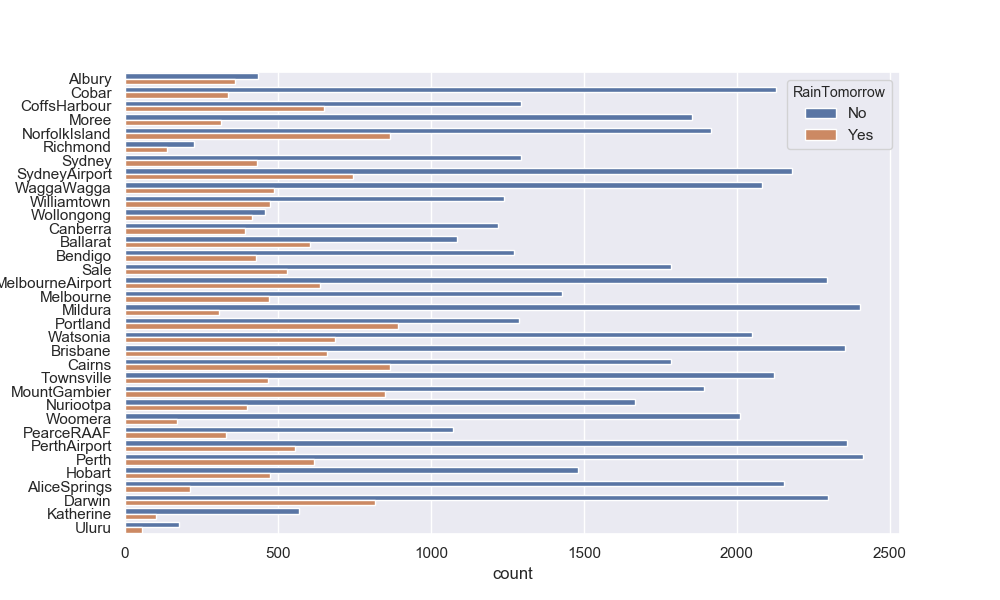

In [ ]:
sns.countplot(y='Location', hue='RainTomorrow', data=not_nan_dataset,)

We notice that location Column is not important so we will delete it

In [ ]:
del not_nan_dataset['Location']

## Date :

We can extract some importaont features from date like seasons :

In [ ]:
# Converting Complete Date to month only (12 category)

months =  [int(date[1]) for date in [comp_date.split('-') for comp_date in not_nan_dataset['Date']] ]
seasons = []
for i in months :
    if i==12 or i >=1 and i <=2 : seasons.append(1)
    if i >=3 and i <=5 : seasons.append(2)
    if i >=6 and i <=8 : seasons.append(3)
    if i >=9 and i <=11 : seasons.append(4)

not_nan_dataset['Date'] = seasons

In [ ]:
not_nan_dataset['Date'].value_counts()

2    18341
3    18072
4    17657
1    16975
Name: Date, dtype: int64

<IPython.core.display.Javascript object>


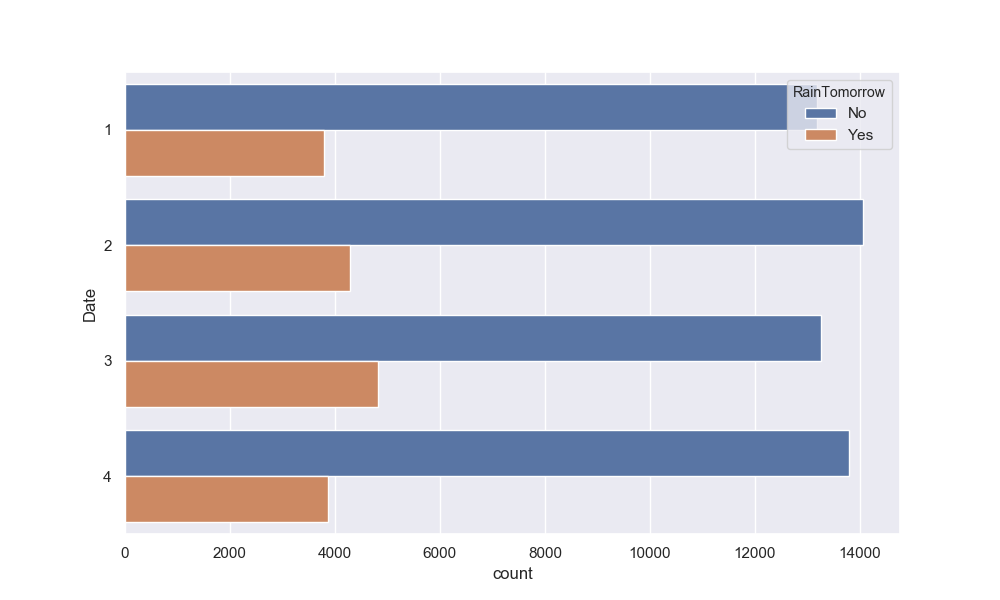

In [ ]:
sns.countplot(y='Date', hue='RainTomorrow', data=not_nan_dataset,)

There are no important information from seasons column .

In [ ]:
# del not_nan_dataset['Date']

In [ ]:
not_nan_dataset.columns

Index(['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir',
       'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
       'RainToday', 'RainTomorrow'],
      dtype='object')

<IPython.core.display.Javascript object>


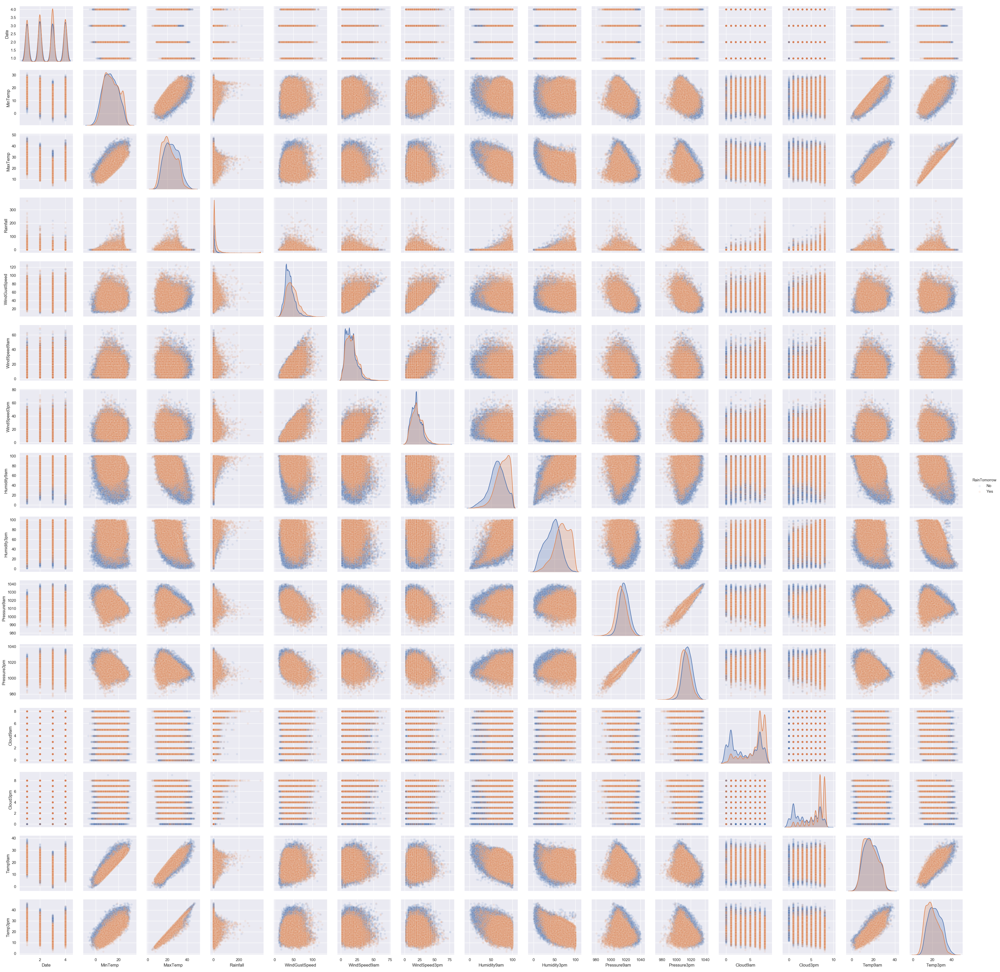

In [ ]:
# sns.countplot(y='Cloud3pm', hue='RainTomorrow', data=df)
sns.pairplot(not_nan_dataset, hue='RainTomorrow', size=2.5 ,  plot_kws={'alpha': 0.1 , 'edgecolors':"none"} );


From the scatter plots above we notice that there are no obvious decesion boundary between the features when we study them as pairs .

In [ ]:
del not_nan_dataset['WindDir9am']

In [ ]:
not_nan_dataset['WindGustDir'].value_counts()

E      5530
W      5409
SW     5168
N      5059
WSW    4965
SSW    4854
SE     4850
ENE    4757
S      4740
SSE    4255
ESE    4148
WNW    3926
NE     3870
NW     3369
NNE    3237
NNW    2908
Name: WindGustDir, dtype: int64

# Preparing data for trainig :

## Balancing the dataset :

In [ ]:
not_nan_dataset['RainTomorrow'].value_counts()

No     54294
Yes    16751
Name: RainTomorrow, dtype: int64

the data is unbalanced so we must delete some negative example befor trainig

In [ ]:
# The Data is unbalanced , we will randomly delete some negative example :

# Removing random records that labeled with No (class with heigher count)

final_dataset = not_nan_dataset.drop(not_nan_dataset[not_nan_dataset['RainTomorrow'] == 'No'].sample(frac=.69).index)
final_dataset['RainTomorrow'].value_counts()


No     16831
Yes    16751
Name: RainTomorrow, dtype: int64

In [ ]:
final_dataset.head()

,Date,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
11,1,15.9,21.7,2.2,NNE,31.0,ENE,15.0,13.0,89.0,91.0,1010.5,1004.2,8.0,8.0,15.9,17.0,Yes,Yes
12,1,15.9,18.6,15.6,W,61.0,NNW,28.0,28.0,76.0,93.0,994.3,993.0,8.0,8.0,17.4,15.8,Yes,Yes
16,1,14.1,20.9,0.0,ENE,22.0,E,11.0,9.0,69.0,82.0,1012.2,1010.4,8.0,1.0,17.2,18.1,No,Yes
17,1,13.5,22.9,16.8,W,63.0,WNW,6.0,20.0,80.0,65.0,1005.8,1002.2,8.0,1.0,18.0,21.5,Yes,Yes
52,1,24.4,34.0,0.6,NW,98.0,NNW,26.0,48.0,60.0,39.0,1005.3,997.8,4.0,1.0,26.1,33.1,No,Yes


## Data Encoding :

Converting the Categorical Data to numeric data :

In [ ]:
print('Dataset shape before encoding :')
print(final_dataset.shape)
print('Dataset columns :')
print(final_dataset.columns)

Dataset shape before encoding :
(33582, 19)
Dataset columns :
Index(['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir',
       'WindGustSpeed', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm',
       'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
       'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')


In [ ]:
final_dataset.dtypes

Date               int64
MinTemp          float64
MaxTemp          float64
Rainfall         float64
WindGustDir       object
WindGustSpeed    float64
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore')

categorical_WindGustDir =  (pd.DataFrame(enc.fit_transform(final_dataset[['WindGustDir']]).toarray())).to_numpy()
categorical_WindDir3pm =  (pd.DataFrame(enc.fit_transform(final_dataset[['WindDir3pm']]).toarray())).to_numpy()
categorical_RainToday =  (pd.DataFrame(enc.fit_transform(final_dataset[['RainToday']]).toarray())).to_numpy()




In [ ]:
final_dataset.columns

Index(['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir',
       'WindGustSpeed', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm',
       'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
       'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [ ]:
new_df = final_dataset.copy()
del new_df['WindGustDir']
del new_df['WindDir3pm']
del new_df['RainToday']
del new_df['RainTomorrow']

In [ ]:
new_df.head()
print(new_df.shape)
print(new_df.columns)

(33582, 15)
Index(['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm'],
      dtype='object')


In [ ]:
features = (new_df.ix[:,range(0,15)]).to_numpy()
final_dataset.RainTomorrow= final_dataset.RainTomorrow.replace(to_replace=['No', 'Yes'], value=[0, 1])

features = np.append(features , categorical_WindGustDir , axis=1)
features = np.append(features , categorical_WindDir3pm , axis=1)
features = np.append(features , categorical_RainToday , axis=1)


target = (final_dataset.RainTomorrow).to_numpy()
print(features.shape)
print(target.shape)


(33582, 49)
(33582,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , roc_auc_score

import matplotlib.pyplot as plt

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features , target , random_state = 0)

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**  Logistic Regression  **

                Rain- Not Rain 
       Rain-   3345.0    776.0 
    Not Rain    945.0   3330.0 

Accuracy on the training subset: 0.795
Accuracy on the test subset: 0.795
Precision: 0.81
Recall: 0.78
F1: 0.79


<IPython.core.display.Javascript object>


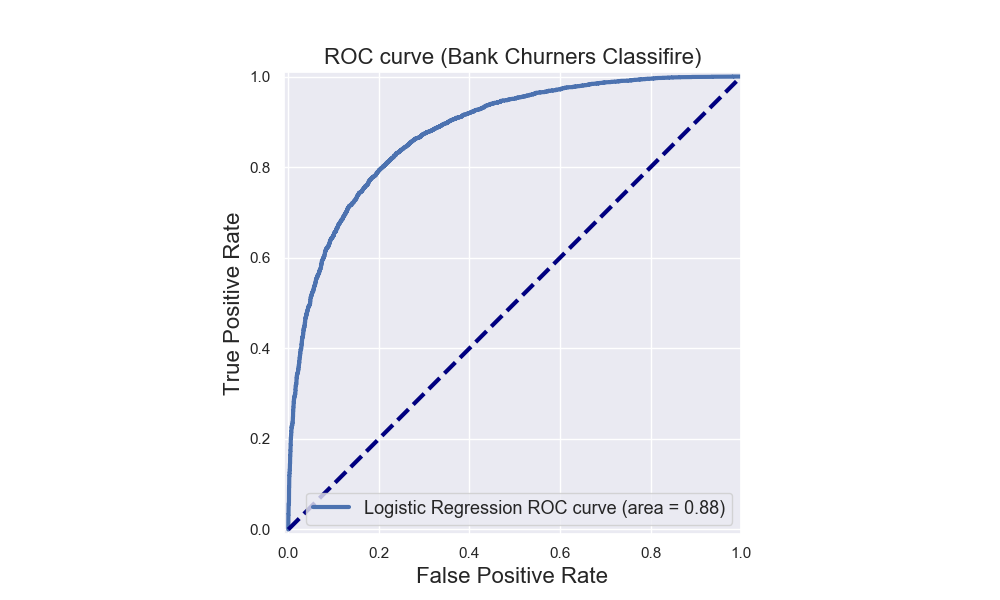

In [ ]:
# Logistic Regression :
print('**  Logistic Regression  **')
print()
log_reg = LogisticRegression().fit(X_train_scaled , y_train)
y_score_lr = log_reg.decision_function(X_test_scaled)
log_reg_predicted = log_reg.predict(X_test_scaled)
confusion = confusion_matrix(y_test, log_reg_predicted)

print_cm(confusion, ['Rain-', 'Not Rain'])

print()
print_results(log_reg , log_reg_predicted , X_train_scaled , y_train , X_test_scaled , y_test)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])
plt.plot(fpr_lr, tpr_lr, lw=3, label='Logistic Regression ROC curve (area = {:0.2f})'.format(roc_auc_lr))
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve (Bank Churners Classifire)', fontsize=16)
plt.legend(loc='lower right', fontsize=13)
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
plt.axes().set_aspect('equal')
plt.show()




**  Support Vector Machine  **

                       Rain -- Not Rain 
           Rain      3349.0       772.0 
    -- Not Rain       868.0      3407.0 
Accuracy on the training subset: 0.824
Accuracy on the test subset: 0.805
Precision: 0.82
Recall: 0.80
F1: 0.81


<IPython.core.display.Javascript object>


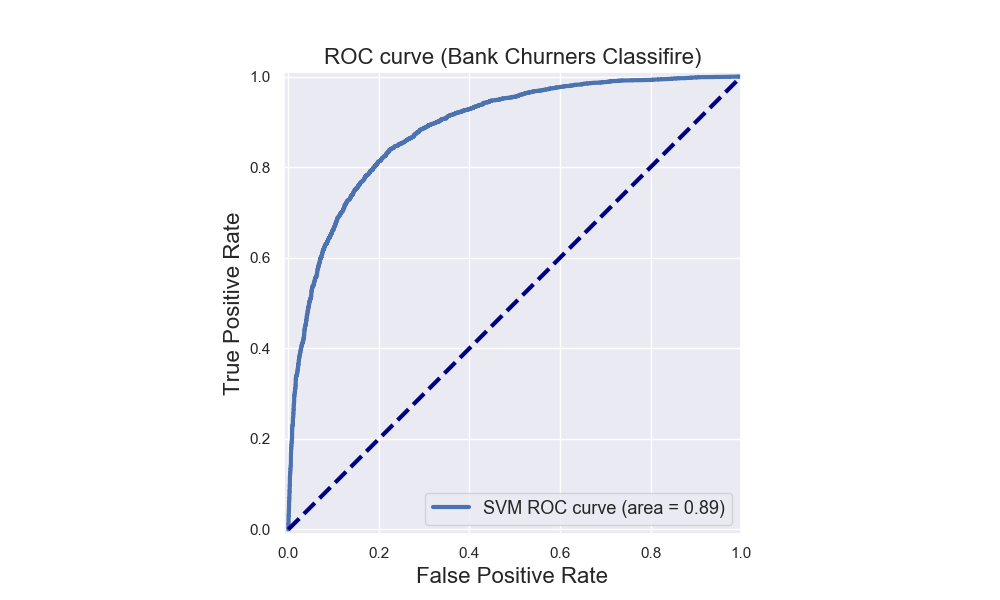

In [ ]:
from sklearn.metrics import roc_curve, auc


svm = SVC(kernel='rbf', C=10 , gamma=0.1)
y_score_lr = svm.fit(X_train_scaled, y_train).decision_function(X_test_scaled)
svm_predicted = svm.predict(X_test_scaled)
confusion = confusion_matrix(y_test, svm_predicted)

print('**  Support Vector Machine  **')
print()
print_cm(confusion, ['Rain', '-- Not Rain'])
print_results(svm , svm_predicted , X_train_scaled , y_train , X_test_scaled , y_test)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])
plt.plot(fpr_lr, tpr_lr, lw=3, label='SVM ROC curve (area = {:0.2f})'.format(roc_auc_lr))
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve (Bank Churners Classifire)', fontsize=16)
plt.legend(loc='lower right', fontsize=13)
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
plt.axes().set_aspect('equal')
plt.show()

In [ ]:
clf = SVC()
grid_values = {'kernel' : ['linear' , 'rbf'] ,
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
               'gamma': [0.001, 0.01, 0.05, 0.1, 1, 10, 100]}

# default metric to optimize over grid parameters: accuracy
grid_clf_acc = GridSearchCV(clf, param_grid = grid_values)
grid_clf_acc.fit(X_train_scaled, y_train)


y_decision_fn_scores_acc = grid_clf_acc.decision_function(X_test_scaled)

print('Grid best parameter (max. accuracy): ', grid_clf_acc.best_params_)
print('Grid best score (accuracy): ', grid_clf_acc.best_score_)

Grid best parameter (max. accuracy):  {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Grid best score (accuracy):  0.8009211466687842


In [ ]:
# DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier


print('** DecisionTreeClassifier **')
print()
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_scaled, y_train)
tree_head = tree.predict(X_test_scaled)
print_results(tree , tree_head , X_train_scaled , y_train , X_test_scaled , y_test)


print(f"""
accuracy_score: {accuracy_score(tree_head, y_test)}
roc_auc_score: {roc_auc_score(tree_head, y_test)}
""")

** DecisionTreeClassifier **

Accuracy on the training subset: 1.000
Accuracy on the test subset: 0.726
Precision: 0.72
Recall: 0.73
F1: 0.73

accuracy_score: 0.725702715578847
roc_auc_score: 0.7257073815540732



In [ ]:
# KNeighborsClassifier

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

knn_head = knn.predict(X_test_scaled)

print_results(knn , knn_head , X_train_scaled , y_train , X_test_scaled , y_test)



print(f"""
accuracy_score: {accuracy_score(knn_head, y_test)}
roc_auc_score: {roc_auc_score(knn_head, y_test)}
""")



Accuracy on the training subset: 0.824
Accuracy on the test subset: 0.744
Precision: 0.73
Recall: 0.76
F1: 0.74

accuracy_score: 0.7440447832301096
roc_auc_score: 0.7442612826171857



In [ ]:
# RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=1)
rfc.fit(X_train_scaled, y_train)
y_predict = rfc.predict(X_test_scaled)
print_results(rfc , y_predict , X_train_scaled , y_train , X_test_scaled , y_test)



Accuracy on the training subset: 0.988
Accuracy on the test subset: 0.784
Precision: 0.82
Recall: 0.74
F1: 0.78


In [ ]:
def print_cm(cm, labels, hide_zeroes=False, hide_diagonal=False, hide_threshold=None):
    """pretty print for confusion matrixes"""
    columnwidth = max([len(x) for x in labels] + [5])  # 5 is value length
    empty_cell = " " * columnwidth
    # Print header
    print("    " + empty_cell, end=" ")
    for label in labels:
        print("%{0}s".format(columnwidth) % label, end=" ")
    print()
    # Print rows
    for i, label1 in enumerate(labels):
        print("    %{0}s".format(columnwidth) % label1, end=" ")
        for j in range(len(labels)):
            cell = "%{0}.1f".format(columnwidth) % cm[i, j]
            if hide_zeroes:
                cell = cell if float(cm[i, j]) != 0 else empty_cell
            if hide_diagonal:
                cell = cell if i != j else empty_cell
            if hide_threshold:
                cell = cell if cm[i, j] > hide_threshold else empty_cell
            print(cell, end=" ")
        print()

In [ ]:
def print_results(model , predicted , x_train , y_train , x_test , y_test ):
    print('Accuracy on the training subset: {:.3f}'.format(model.score(x_train, y_train)))
    print('Accuracy on the test subset: {:.3f}'.format(model.score(x_test, y_test)))
    print('Precision: {:.2f}'.format(precision_score(y_test, predicted)))
    print('Recall: {:.2f}'.format(recall_score(y_test, predicted)))
    print('F1: {:.2f}'.format(f1_score(y_test, predicted)))
